## Lorenz63 Benchmarks

### config


In [1]:
import torch
import matplotlib.pyplot as plt 
from lorenz import Lorenz63, TimeAveragedFeatures

N = 500
T = 360
spinup = 30
dt = 0.01
params = {
    'sigma':10,
    'beta':8/3,
    'rho':28 
}
l63 = Lorenz63(**params)
x0 = torch.randn((N,3))
r = l63(x0,T,dt)
l63_avg = TimeAveragedFeatures(l63,spinup=spinup)

r_avg = l63_avg(x0,T,dt)


In [2]:
r_avg_norm = (r_avg - r_avg.mean(dim=0))/r_avg.std(dim=0)

In [3]:
from lorenz import get_polynomial_features
spunup0 = get_polynomial_features(r[0,int(spinup/dt):])
t = int(10/dt)

In [4]:
chunks = spunup0.reshape(int((T-spinup)/(dt*t)), t, 9)
chunk_mean = chunks.mean(axis=1)

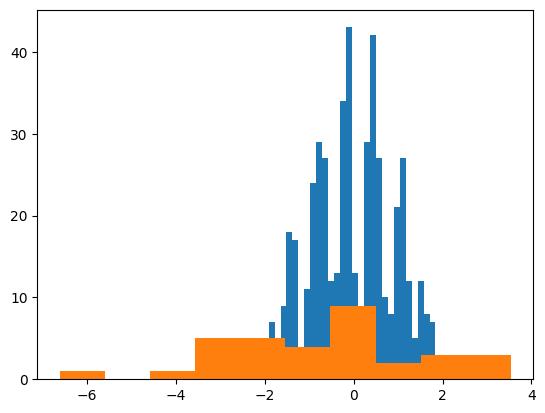

In [5]:

with torch.no_grad():
    plt.hist(r_avg_norm[:,4],bins=50)
    plt.hist(chunk_mean[:,0],bins=10)

In [6]:
from torch.distributions import MultivariateNormal
stats = MultivariateNormal(r_avg_norm.mean(dim=0),torch.cov(r_avg_norm.T))
true_cov = torch.cov(r_avg_norm.T) * (T - spinup)

In [7]:
noise_level = torch.sqrt(torch.linalg.eigh(torch.cov(r_avg.T)).eigenvalues.max())

### calibration

In [8]:
from torch.distributions import MultivariateNormal,Uniform
from abracalibra.forward_model import ForwardModel

priors = {
    'sigma':Uniform(5,15),
    'beta':Uniform(1,5),
    'rho':Uniform(25,30)
} # these are probably too wide priors!


N = 1
x0 = torch.randn((N,3))

def lorenz63(sigma,beta,rho):
    with torch.no_grad():
        l = TimeAveragedFeatures(Lorenz63(sigma.clone(),beta.clone(),rho.clone()),spinup=spinup)
        fwd = l(x0,T,dt)
        return (fwd[0] - r_avg.mean(dim=0))/(r_avg.std(dim=0))

fwd = ForwardModel(lorenz63,vectorized=False)

In [23]:
from abracalibra.history_matching import HistoryMatchingBase
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.emulators import MultiTaskGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.priors import NormalPrior

class HistoryMatchingLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.output_mc_batchshape:
            target_shape = torch.Size((*parameters.shape[:-1], *self.output_mc_batchshape, self.number_of_parameters))
            parameters = parameters.unsqueeze(-2).expand(*target_shape)
            parameters = parameters.reshape(-1, self.number_of_parameters)
        else:
            parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,
            noise_prior=NormalPrior(1,0.001)

        )
        likelihood.noise = 1 
        model = MultiTaskGP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

In [24]:
from abracalibra.eki import EnsembleKalmanInversion
from scipy.stats import chi2
from abracalibra.summary import implausibility_multivariate_distr
parameters = ['sigma','beta','rho']
def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

priors = {
    'sigma':Uniform(9,11),
    'beta':Uniform(2,3),
    'rho':Uniform(25,30)
} # th
cutoff = chi2(stats.mean.shape[0]).ppf(0.95)
hm = HistoryMatchingLorenz(parameters,priors,stats,ensemble_size=30,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(1)

Step 0 Loss: 257.1258850097656
Step 1 Loss: 248.1656494140625
Step 2 Loss: 242.76278686523438
Step 3 Loss: 237.26754760742188
Step 4 Loss: 230.59054565429688
Step 5 Loss: 223.63214111328125
Step 6 Loss: 217.0052947998047
Step 7 Loss: 210.7425537109375
Step 8 Loss: 204.46853637695312
Step 9 Loss: 197.89962768554688
Step 10 Loss: 191.12228393554688
Step 11 Loss: 184.43174743652344
Step 12 Loss: 178.0770263671875
Step 13 Loss: 172.11444091796875
Step 14 Loss: 166.4202423095703
Step 15 Loss: 160.8489990234375
Step 16 Loss: 155.376708984375
Step 17 Loss: 150.09751892089844
Step 18 Loss: 145.12254333496094
Step 19 Loss: 140.48814392089844
Step 20 Loss: 136.1351318359375
Step 21 Loss: 131.96502685546875
Step 22 Loss: 127.9166488647461
Step 23 Loss: 123.9988021850586
Step 24 Loss: 120.25830841064453
Step 25 Loss: 116.72774505615234
Step 26 Loss: 113.39215850830078
Step 27 Loss: 110.2021255493164
Step 28 Loss: 107.1158218383789
Step 29 Loss: 104.13043212890625
Step 30 Loss: 101.27520751953125
S

In [25]:
hm.emulators[0].likelihood.noise

tensor([1.0012], grad_fn=<AddBackward0>)

In [ ]:
from gpytorch.settings import fast_pred_var
NPOINTS = 100
nroy,coords= hm.nroy_over_support(num_points=100,return_coords=True)
coords = hm.get_support_axis(0,NPOINTS)
X,Y,Z = torch.meshgrid(*coords,indexing='ij')

emulator = hm.emulators[0]
emulator.eval()


with fast_pred_var(), torch.no_grad():
    pred = emulator(torch.stack([X,Y,Z],dim=-1).view(-1,3))
    imp = hm.implausibility(torch.stack([X,Y,Z],dim=-1).view(-1,3),0)
    
    pred_mean = pred.mean.view(NPOINTS,NPOINTS,NPOINTS,9)
    imp = imp.view(NPOINTS,NPOINTS,NPOINTS)


torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


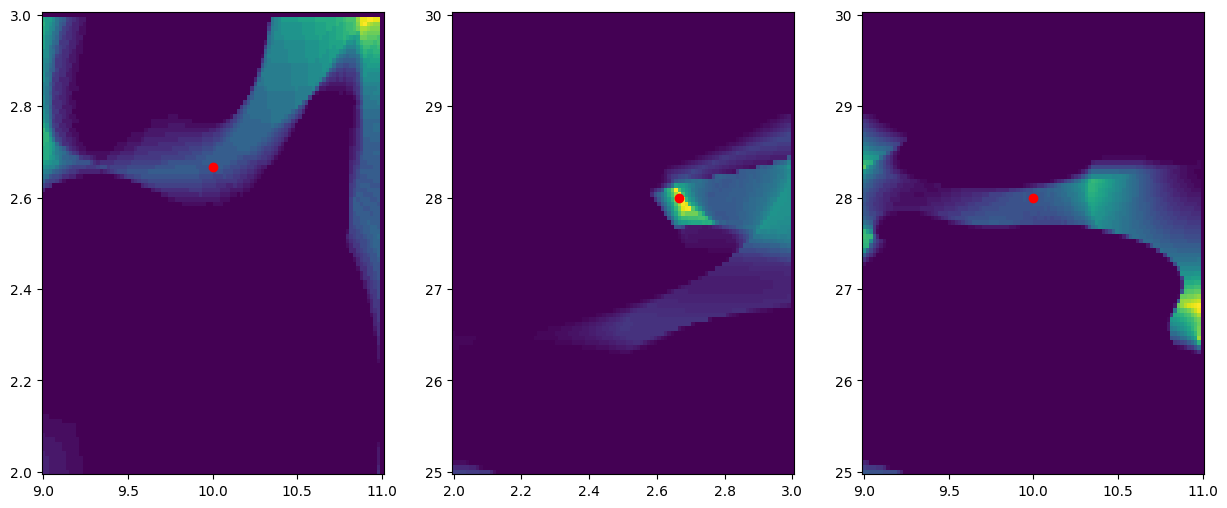

In [28]:
import matplotlib.pyplot as plt
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(15,6))
X,Y = torch.meshgrid(coords[0],coords[1],indexing='xy')
ax1.pcolormesh(X,Y,nroy.sum(dim=2).T/100)
ax1.scatter(params['sigma'],params['beta'],color='r')

X,Y = torch.meshgrid(coords[1],coords[2],indexing='xy')
ax2.pcolormesh(X,Y,nroy.sum(dim=0).T/100)
ax2.scatter(params['beta'],params['rho'],color='r')
X,Y = torch.meshgrid(coords[0],coords[2],indexing='xy')
ax3.pcolormesh(X,Y,nroy.sum(dim=1).T/100)
ax3.scatter(params['sigma'],params['rho'],color='r')

In [ ]:
hm = HistoryMatchingLorenz(parameters,priors,stats,ensemble_size=30,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(3)

Step 0 Loss: 167.04367065429688
Step 1 Loss: 156.20254516601562
Step 2 Loss: 147.23374938964844
Step 3 Loss: 138.21067810058594
Step 4 Loss: 130.26742553710938
Step 5 Loss: 123.53925323486328
Step 6 Loss: 117.35433959960938
Step 7 Loss: 111.41278839111328
Step 8 Loss: 105.92618560791016
Step 9 Loss: 101.07096099853516
Step 10 Loss: 96.72566986083984
Step 11 Loss: 92.64096069335938
Step 12 Loss: 88.75509643554688
Step 13 Loss: 85.18421173095703
Step 14 Loss: 82.01272583007812
Step 15 Loss: 79.17800903320312
Step 16 Loss: 76.55064392089844
Step 17 Loss: 74.0828628540039
Step 18 Loss: 71.8250961303711
Step 19 Loss: 69.82432556152344
Step 20 Loss: 68.04530334472656
Step 21 Loss: 66.40093231201172
Step 22 Loss: 64.8443832397461
Step 23 Loss: 63.396244049072266
Step 24 Loss: 62.08465576171875
Step 25 Loss: 60.889259338378906
Step 26 Loss: 59.75690841674805
Step 27 Loss: 58.659698486328125
Step 28 Loss: 57.61394500732422
Step 29 Loss: 56.64234924316406
Step 30 Loss: 55.73561096191406
Step 31 

## Ensemble Kalman Inversion (L63)

In [14]:
from abracalibra.eki import EnsembleKalmanInversion

eki = EnsembleKalmanInversion(parameters,priors,observables,ensemble_size=30,forward=fwd)
eki.calibrate(5)

tensor([ 9.9812,  2.6643, 27.9959], grad_fn=<MeanBackward1>)

<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:13: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:18: SyntaxWarning: invalid escape sequence '\{'
<>:19: SyntaxWarning: invalid escape sequence '\{'
<string>:7: SyntaxWarning: invalid escape sequence '\{'
<string>:8: SyntaxWarning: invalid escape sequence '\{'
<string>:13: SyntaxWarning: invalid escape sequence '\{'
<string>:14: SyntaxWarning: invalid escape sequence '\{'
<string>:18: SyntaxWarning: invalid escape sequence '\{'
<string>:19: SyntaxWarning: invalid escape sequence '\{'
<>:7: SyntaxWarn

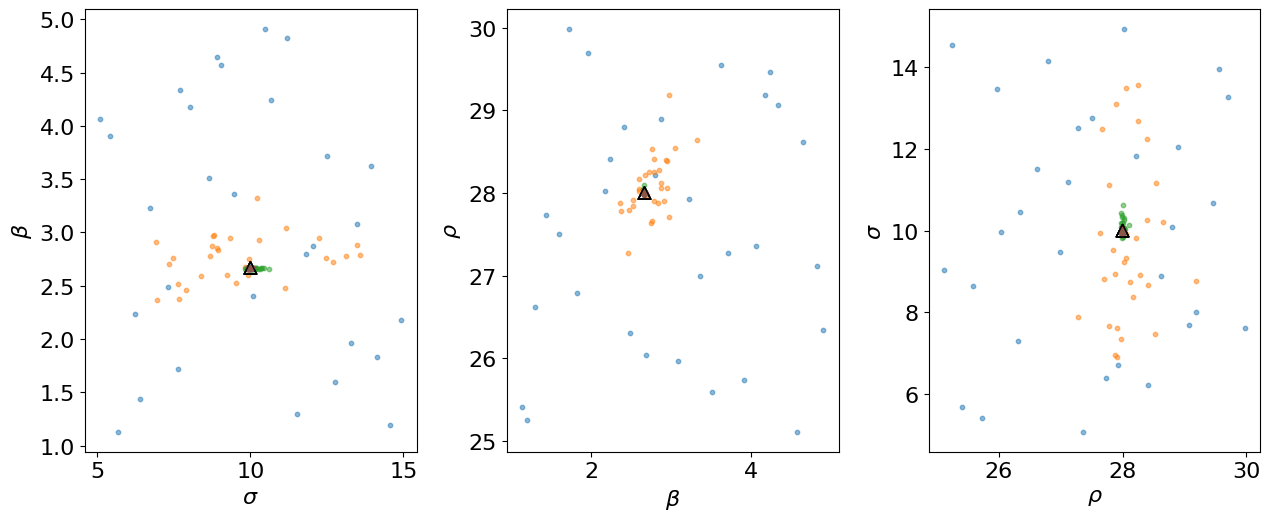

In [18]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(13,5.5))
plt.rcParams.update({'font.size': 16})
with torch.no_grad():
    for p in eki.parameters:
        ax1.scatter(p[:, 0], p[:, 1], alpha=0.5, s=10)
        ax1.scatter(true_params['sigma'],true_params['beta'],color='none',marker='^',s=80,edgecolor='black')
        ax1.set_xlabel(f"$\{parameters[0]}$")
        ax1.set_ylabel(f"$\{parameters[1]}$")


        ax2.scatter(p[:, 1], p[:, 2], alpha=0.5, s=10)
        ax2.scatter(true_params['beta'],true_params['rho'],color='none',marker='^',s=80,edgecolor='black')
        ax2.set_xlabel(f"$\{parameters[1]}$")
        ax2.set_ylabel(f"$\{parameters[2]}$")

        ax3.scatter(p[:, 2], p[:, 0], alpha=0.5, s=10)
        ax3.scatter(true_params['rho'],true_params['sigma'],color='none',marker='^',s=80,edgecolor='black')
        ax3.set_xlabel(f"$\{parameters[2]}$")
        ax3.set_ylabel(f"$\{parameters[0]}$")
fig.tight_layout()
fig.savefig('lorenz63_eki.png',dpi=300) 

## d = 2

In [15]:
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask,HistoryMatchingBase
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from abracalibra.emulators import MultiTaskGPMatern
from abracalibra.summary import implausibility_multivariate_distr

class HistoryMatchingMultTaskLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(num_tasks=self.number_of_observables)
        # likelihood.noise = 1e-2
        model = MultiTaskGPMatern(
            parameters, observations,likelihood=likelihood, num_tasks=self.number_of_observables
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(500):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model 


parameters = ['sigma','rho']
priors = {
    'rho': Uniform(25,35),
    'sigma':Uniform(5,15)
} 
def summary(y,true_y):
    return implausibility_multivariate_distr(y,true_y)

fwd_d2 = ForwardModel(lorenz63,vectorized=False,beta=torch.as_tensor(true_params['beta']))
from scipy.stats import chi2


cutoff = torch.tensor(chi2(torch.linalg.matrix_rank(observables.covariance_matrix)).isf(0.01))
hm_d2 = HistoryMatchingMultTaskLorenz(parameters,priors,observables,ensemble_size=20,summary=summary,forward=fwd_d2,implausibility_cutoff=cutoff)
hm_d2.calibrate(1)

[Uniform(low: 5.0, high: 15.0), Uniform(low: 25.0, high: 35.0)]
tensor(6.1140) tensor(2.6667) tensor(33.6286)
tensor(5.8743) tensor(2.6667) tensor(34.7459)
tensor(5.2459) tensor(2.6667) tensor(30.8841)
tensor(9.1995) tensor(2.6667) tensor(26.8276)
tensor(7.9548) tensor(2.6667) tensor(25.6126)
tensor(9.6351) tensor(2.6667) tensor(31.9954)
tensor(14.8852) tensor(2.6667) tensor(29.8482)
tensor(11.0497) tensor(2.6667) tensor(26.2097)
tensor(12.4740) tensor(2.6667) tensor(32.4232)
tensor(13.4832) tensor(2.6667) tensor(33.0270)
tensor(11.9806) tensor(2.6667) tensor(30.0858)
tensor(13.7501) tensor(2.6667) tensor(28.4761)
tensor(8.1181) tensor(2.6667) tensor(31.0747)
tensor(7.2704) tensor(2.6667) tensor(28.5795)
tensor(12.7415) tensor(2.6667) tensor(32.9349)
tensor(14.2650) tensor(2.6667) tensor(29.1932)
tensor(10.8336) tensor(2.6667) tensor(27.6937)
tensor(8.7766) tensor(2.6667) tensor(25.2531)
tensor(10.0197) tensor(2.6667) tensor(34.0023)
tensor(6.6054) tensor(2.6667) tensor(27.2612)
Step 0

In [21]:
nroy,coords= hm_d2.nroy_over_support(num_points=250,return_coords=True)

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [22]:
hm_d2.implausibility(torch.tensor([10,28]),0)

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


tensor([8.2821], grad_fn=<CatBackward0>)

Text(0, 0.5, '$\\sigma$')

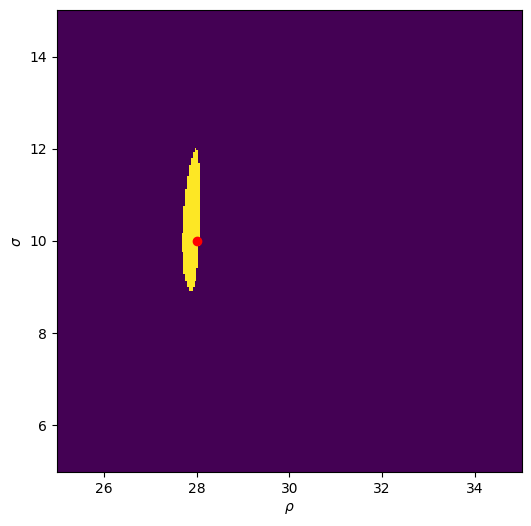

In [29]:
fig,ax = plt.subplots(1,1,figsize=(6,6))
X,Y = torch.meshgrid(coords[0],coords[1],indexing='ij')
ax.pcolormesh(Y,X,nroy)
ax.scatter(true_params['rho'],true_params['sigma'],color='r')
ax.set_xlabel('$\\rho$')
ax.set_ylabel('$\\sigma$')

In [19]:
parameters = ['rho',]
priors = {
    'rho':Uniform(25,30)
} 
def summary(y,true_y):
    return implausibility_multivariate_distr(y,true_y)

from scipy.stats import chi2


cutoff = torch.tensor(chi2(torch.linalg.matrix_rank(observables.covariance_matrix)).isf(0.01))

fwd_d1 = ForwardModel(lorenz63,vectorized=False,beta=torch.as_tensor(true_params['beta']),sigma=torch.as_tensor(true_params['sigma']))
hm_d1 = HistoryMatchingMultTaskLorenz(parameters,priors,observables,ensemble_size=10,summary=summary,forward=fwd_d1,implausibility_cutoff=cutoff)
hm_d1.calibrate(2)

[Uniform(low: 25.0, high: 30.0)]
tensor(10) tensor(2.6667) tensor(29.3502)
tensor(10) tensor(2.6667) tensor(27.9989)
tensor(10) tensor(2.6667) tensor(27.0964)
tensor(10) tensor(2.6667) tensor(28.4928)
tensor(10) tensor(2.6667) tensor(25.1447)
tensor(10) tensor(2.6667) tensor(25.5340)
tensor(10) tensor(2.6667) tensor(26.3173)
tensor(10) tensor(2.6667) tensor(26.6630)
tensor(10) tensor(2.6667) tensor(28.5250)
tensor(10) tensor(2.6667) tensor(29.7543)
Step 0 Loss: 9867.9677734375
Step 1 Loss: 9317.8681640625
Step 2 Loss: 8786.3779296875
Step 3 Loss: 8273.1982421875
Step 4 Loss: 7775.580078125
Step 5 Loss: 7290.59423828125
Step 6 Loss: 6817.08544921875
Step 7 Loss: 6354.7529296875
Step 8 Loss: 5903.87451171875
Step 9 Loss: 5464.76318359375
Step 10 Loss: 5038.16162109375
Step 11 Loss: 4625.873046875
Step 12 Loss: 4230.17431640625
Step 13 Loss: 3853.500244140625
Step 14 Loss: 3498.861083984375
Step 15 Loss: 3170.197998046875
Step 16 Loss: 2870.8095703125
Step 17 Loss: 2602.04150390625
Step 1

KeyboardInterrupt: 

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


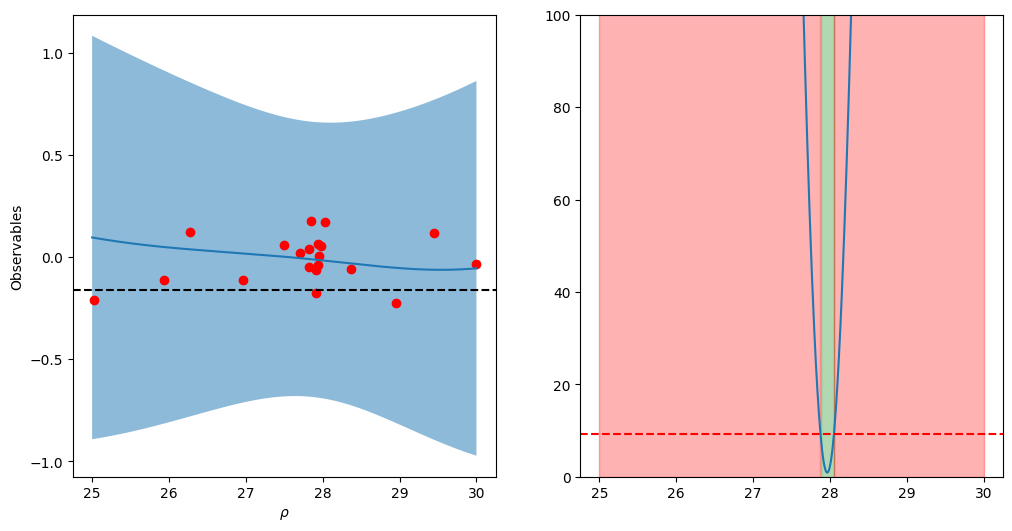

In [24]:
em = hm_d1.emulators[hm_d1.current_wave - 1]
rho = torch.linspace(25,30,500)
pred = em(rho.view(-1,1))
plot_var = 1
fig, (ax1,ax2)= plt.subplots(1,2,figsize=(12,6))
imp = hm_d1.implausibility(rho.view(-1,1),hm_d1.current_wave - 1)
with torch.no_grad():
    ax1.plot(rho,pred.mean[:,plot_var])
    lower,upper = pred.confidence_region()
    ax1.fill_between(rho,lower[:,plot_var],upper[:,plot_var],alpha=0.5)
    ax1.scatter(hm_d1.params[:,:,0].ravel(),hm_d1.results[:,:,plot_var].ravel(),color='r')
    ax1.axhline(observables.mean[plot_var],color='black',linestyle='--')
    ax1.set_xlabel('$\\rho$')
    ax1.set_ylabel('Observables')
    
    ax2.plot(rho,imp)
    ax2.set_ylim(0,100)
    ax2.axhline(hm_d1.implausibility_cutoff,color='r',linestyle='--')
    ax2.fill_between(rho,torch.zeros_like(rho),torch.ones_like(rho)*imp.max(),alpha=0.3,color='green',where=imp<9.2)
    ax2.fill_between(rho,torch.zeros_like(rho),torch.ones_like(rho)*imp.max(),alpha=0.3,color='red',where=imp>=9.2)
    
